### Análisis estadístico de la categoría "Audio, Sound & Recording Gear"

In [43]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import mannwhitneyu
import seaborn as sns
import plotly.express as px
from tqdm import tqdm


In [44]:
df_audio = pd.read_csv('../Datasets/amazon_final.csv')
df_audio = df_audio[df_audio['product_category'] == 'Audio, Sound & Recording Gear']
df_audio.head()

,product_title,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,is_best_seller,is_sponsored,coupon,buy_box_availability,sustainability_tags,product_image_url,has_coupon,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,1,Carbon impact,https://m.media-amazon.com/images/I/71pAqiVEs3...,1,"Audio, Sound & Recording Gear",43.60
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,1,NaN,https://m.media-amazon.com/images/I/61h78MEXoj...,0,"Audio, Sound & Recording Gear",10.03
27,"Sony ZX Series Wired On-Ear Headphones, Black ...",4.5,108926.0,10000.0,9.54,9.54,Best Seller,Organic,No Coupon,0,NaN,https://m.media-amazon.com/images/I/41CiQ7hR31...,0,"Audio, Sound & Recording Gear",0.00
58,"PHILIPS TAT1108 Wireless Earbuds,True Wireless...",3.9,6335.0,500.0,29.99,32.72,No Badge,Sponsored,Save $10.00 with coupon,1,NaN,https://m.media-amazon.com/images/I/61nxbYHTWK...,1,"Audio, Sound & Recording Gear",8.34
66,Logitech Brio 101 Full HD 1080p Webcam for Mee...,4.4,24693.0,10000.0,39.59,39.59,Best Seller,Organic,No Coupon,1,Carbon impact,https://m.media-amazon.com/images/I/71A0Pp767B...,0,"Audio, Sound & Recording Gear",0.00


In [45]:
def info_df(df):
    return pd.DataFrame({
    'Columna': df.columns,
    'No Nulos': df.notnull().sum().values,
    'Nulos': df.isnull().sum().values,
    'Tipo Python': df.dtypes.values,
    'Núm. valores': [len(df[col].unique()) for col in df.columns]
     })
info = info_df(df_audio)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,product_title,3413,0,object,747
1,product_rating,3399,14,float64,17
2,total_reviews,3399,14,float64,660
3,purchased_last_month,3002,411,float64,19
4,discounted_price,3342,71,float64,499
5,original_price,3342,71,float64,437
6,is_best_seller,3413,0,object,4
7,is_sponsored,3413,0,object,2
8,coupon,3413,0,object,8
9,buy_box_availability,3413,0,int64,2


# Gráficas sobre variables relevantes individuales.

In [46]:
df_audio[df_audio['is_best_seller'] == 'No Badge']['is_best_seller'].count()


3257

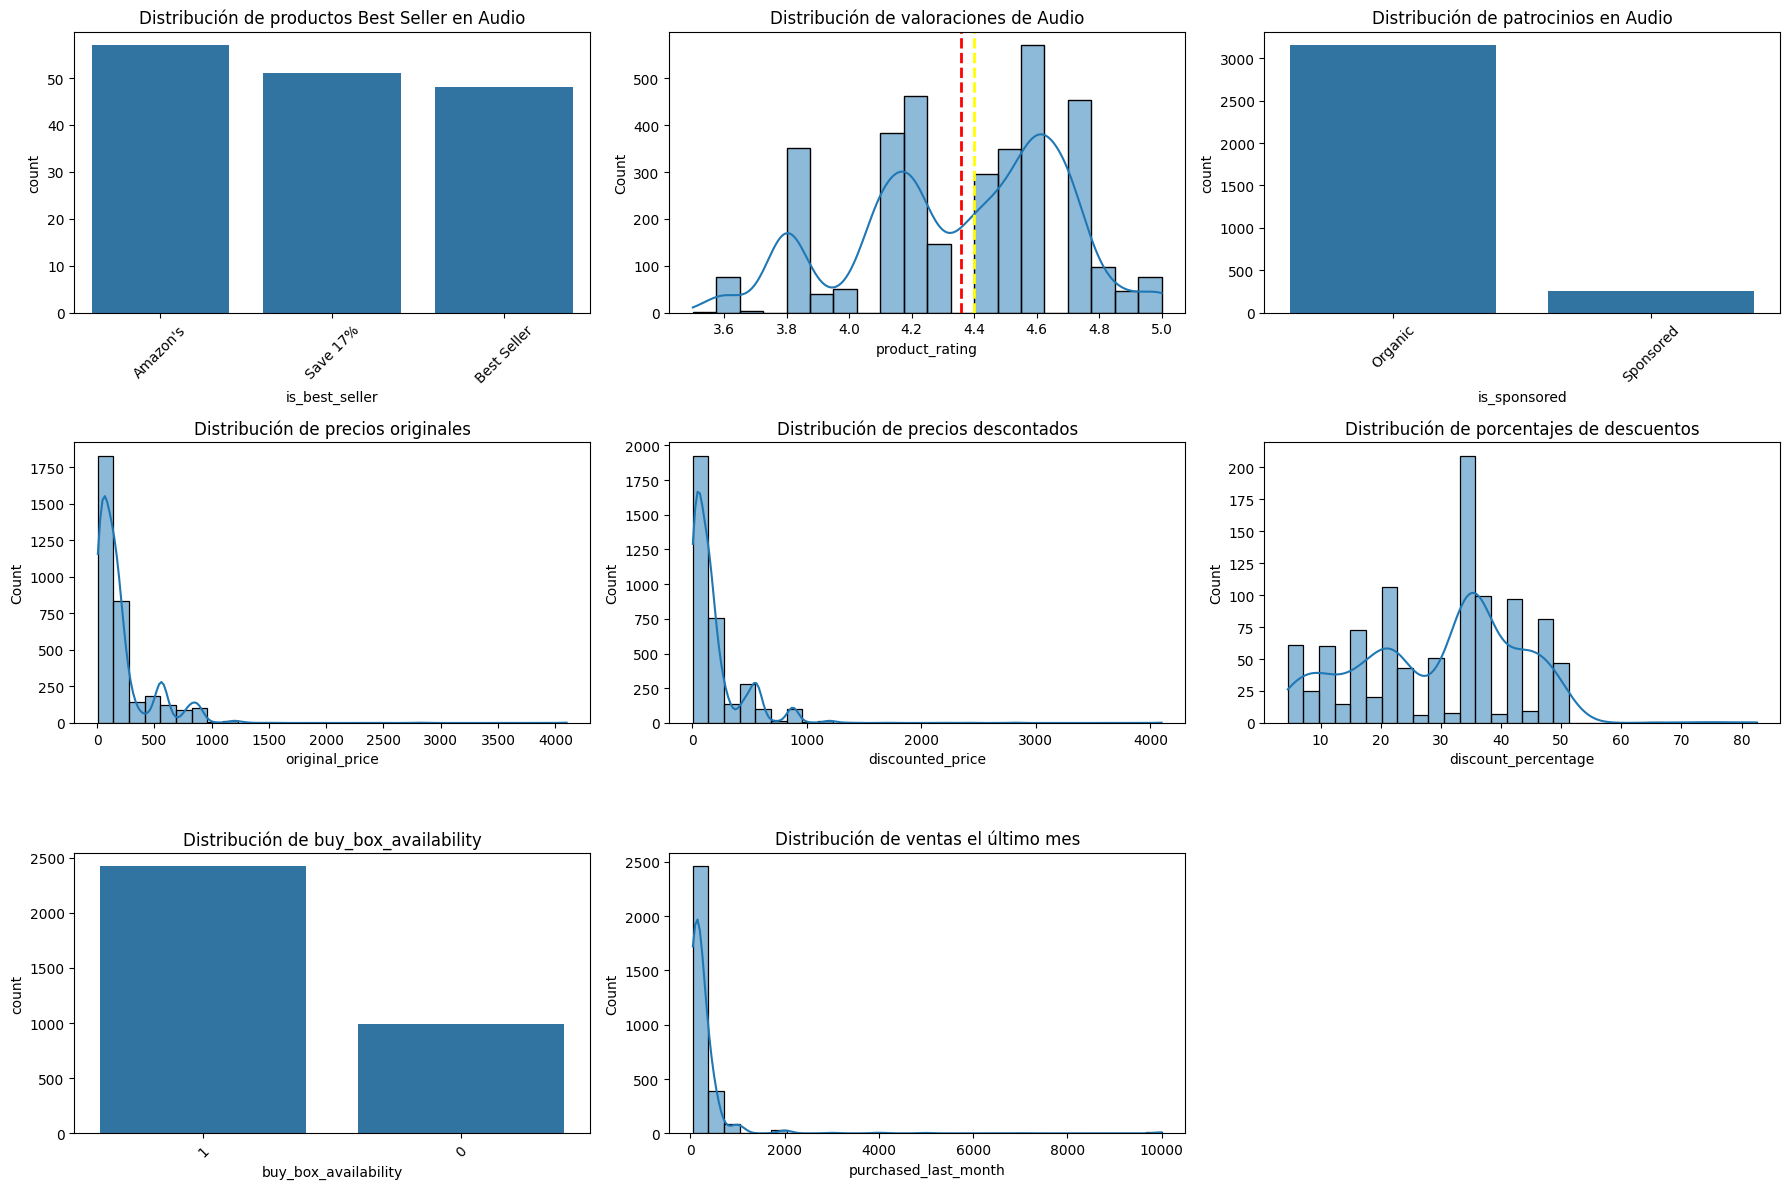

In [51]:
audio_sin_noBadge = df_audio[df_audio['is_best_seller'] != 'No Badge']

# FIGURA DE 3 FILAS X 3 COLUMNAS
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

# Distribución de los valores de best seller
ax = axes[0][0]
sns.countplot(
    data=audio_sin_noBadge,
    x='is_best_seller',
    order=audio_sin_noBadge['is_best_seller'].value_counts().index,
    ax=ax
)
ax.set_title('Distribución de productos Best Seller en Audio')
ax.tick_params(axis='x', rotation=45)
ax.set_visible(True)

# Distribución de las valoraciones de los productos Audio, Sound & Recording Gear
ax = axes[0][1]
sns.histplot(
    df_audio['product_rating'].dropna(),
    bins=20, kde=True, ax=ax
)
valoracion_media = df_audio['product_rating'].mean()
ax.axvline(valoracion_media,color='red', linestyle='--', linewidth=2, label=f'Media: {valoracion_media:.2f}')
valoracion_mediana = df_audio['product_rating'].median()
ax.axvline(valoracion_mediana,color='yellow', linestyle='--', linewidth=2, label=f'Media: {valoracion_mediana:.2f}')
ax.set_title('Distribución de valoraciones de Audio')
ax.set_visible(True)

# -----------------------------------------------------------
# GRAFICA 3 (OCULTA)
# -----------------------------------------------------------
ax = axes[0][2]
sns.countplot(
    data=df_audio,
    x='is_sponsored',
    order=audio_sin_noBadge['is_sponsored'].value_counts().index,
    ax=ax
)
ax.set_title('Distribución de patrocinios en Audio')
ax.tick_params(axis='x', rotation=45)
ax.set_visible(True)

# -----------------------------------------------------------
# GRAFICA 4 (OCULTA)
# -----------------------------------------------------------
ax = axes[1][0]
sns.histplot(
    df_audio['original_price'].dropna(),
    bins=30, kde=True, ax=ax
)
ax.set_title('Distribución de precios originales')
ax.set_visible(True)
# -----------------------------------------------------------
# GRAFICA 5 (OCULTA)
# -----------------------------------------------------------
ax = axes[1][1]
sns.histplot(
    df_audio['discounted_price'].dropna(),
    bins=30, kde=True, ax=ax
)
ax.set_title('Distribución de precios descontados')
ax.set_visible(True)
# -----------------------------------------------------------
# GRAFICA 6 (OCULTA)
# -----------------------------------------------------------
ax = axes[1][2]
sns.histplot(
    df_audio[df_audio['discount_percentage'] > 0].discount_percentage.dropna(),
    bins=30, kde=True, ax=ax
)
ax.set_title('Distribución de porcentajes de descuentos')
ax.set_visible(True)
# -----------------------------------------------------------
# GRAFICA 7 (OCULTA)
# -----------------------------------------------------------
ax = axes[2][0]
df_audio.buy_box_availability = df_audio.buy_box_availability.fillna('No')
sns.countplot(
    data=df_audio,
    x='buy_box_availability',
    order=df_audio.buy_box_availability.value_counts().index,
    ax=ax
)
ax.set_title('Distribución de buy_box_availability')
ax.tick_params(axis='x', rotation=45)
ax.set_visible(True)

ax = axes[2][1]
sns.histplot(
    df_audio['purchased_last_month'].dropna(),
    bins=30, kde=True, ax=ax
)
ax.set_title('Distribución de ventas el último mes')
ax.set_visible(True)
axes[2][2].set_visible(False)

plt.tight_layout()
plt.show()

- *1. Distribución de productos Best Seller:* La gran mayoría de estos productos (3257 de 3413) no tienen ninguna distinción especial resaltada por Amazon en los resultados de búsqueda (No Badge). Existe un equilibrio entre las etiquetas de "Amazon's Choice", "Best Seller" y descuentos específicos (Save 17%). Esto indica que la categoría no está dominada por un solo tipo de reconocimiento, lo que sugiere una competencia alta donde diferentes estrategias de marketing conviven.

- *2. Distribución de valoraciones (Rating):* Los clientes son muy exigentes. La mayoría de los productos tienen notas muy altas, entre 4.4 y 4.7. Si un producto baja de 4 estrellas, se queda "fuera de juego", ya que casi todo lo que se vende bien tiene una puntuación excelente.

- *3. Distribución de patrocinios (Is_sponsored):* La gran mayoría de los productos aparecen de forma natural (orgánica). Esto es positivo para nuestro estudio porque significa que los precios que vemos no están tan "inflados" o manipulados por el gasto en publicidad.

- *4. Distribución de precios (Originales y Descontados):* Casi todo el mundo compra productos de audio "baratos" o de gama media (menos de 200€-300€). Aunque hay algunos equipos profesionales carísimos que llegan a los 4000€, son casos muy aislados. La verdadera guerra de precios ocurre en la zona de bajo coste.

- *5. Distribución de porcentajes de descuentos:* Hay dos estrategias claras: rebajas pequeñas (del 15%) para mantener el margen, o rebajas muy fuertes de casi el 35%. Parece que el 35% es el "número mágico" que usan los vendedores para llamar la atención cuando quieren vender mucho rápido.

- *6. Distribución de buy_box_availability:* La mayoría de los productos están disponibles y listos para comprar. Sin embargo, hay un grupo considerable que no tiene el botón activo; esto suele pasar cuando el producto se queda sin stock o cuando el vendedor pone un precio tan raro que Amazon lo "castiga" ocultando el botón.

- *7. Distribución de ventas (purchased_last_month):* Se cumple la regla de "pocos venden mucho". Hay unos pocos productos "estrella" que tienen miles de ventas, mientras que la inmensa mayoría de los productos tienen ventas modestas (menos de 500 al mes). Es un mercado de unos pocos líderes y muchos seguidores.

# OUTLIERS Y RELACIONES ENTRE VARIABLES

In [52]:
fig = px.box(df_audio, x="original_price", y='is_sponsored',width=1000, height=500)
fig.show()

In [54]:
# Ver los productos de más de 2000 euros
print(df_audio[df_audio['original_price'] > 2000][['product_title', 'original_price']])

                                           product_title  original_price
2479   DJI Air 3S Drone with RC 2 Fly More Combo (wit...         2398.00
4763   DJI Mini 4 Pro Folding Drone with RC 2 Remote ...         2849.99
7201   Nakamichi Dragon 11.4.6 Home Surround Sound Sy...         2799.99
9547   Nakamichi Shockwafe 11.2.6 Channel Dolby Atmos...         2199.99
9695   Sony Alpha FX3 Full-Frame Cinema Line Camera B...         4098.00
10386  Sony Alpha FX3 Full-Frame Cinema Line Camera B...         4098.00


La gráfica muestra que los productos patrocinados (Sponsored) se concentran exclusivamente en el rango de bajo precio, buscando captar volumen de ventas. Por el contrario, los productos orgánicos presentan una dispersión extrema (hasta los 4.000€). Estos valores tan altos actúan como outliers que "aplastan" visualmente las cajas, ocultando el precio medio real del mercado de consumo.

La solución podría estar en aplicar el Rango Intercuartílico para establecer un límite matemático objetivo. De esta forma, podemos separar los productos en dos categorías: Audio de Consumo (el estándar) y Audio Profesional/High-End (los valores atípicos). Esto permite que el análisis de precios sea mucho más preciso, evitando que los equipos de lujo distorsionen las conclusiones del mercado masivo.

In [55]:
# Esto agrupa de 4.0 a 4.2, 4.3 a 4.5, etc.
bins = [0, 3.9, 4.2, 4.5, 4.8, 5.0]
labels = ['< 4.0', '4.0 - 4.2', '4.3 - 4.5', '4.6 - 4.8', '4.9 - 5.0']
df_audio['rating_range'] = pd.cut(df_audio['product_rating'], bins=bins, labels=labels)

# 3. Generamos el Boxplot
fig = px.box(df_audio, 
             x="rating_range", 
             y="original_price",
             color="rating_range",
             points="outliers",      # Muestra los puntos que se salen de lo normal
             hover_data=['product_title'],   # Al pasar el ratón verás el nombre del producto
             title="Análisis: ¿Lo más caro es realmente lo mejor valorado?",
             category_orders={"rating_range": labels},
             labels={'rating_range': 'Valoración (Rating)', 'original_price': 'Precio (€)'})

fig.show()

El análisis del gráfico revela que el mercado de audio en Amazon está dominado por productos de consumo masivo con precios inferiores a 500€, pero lo más revelador ocurre en los extremos de valoración. Mientras que los productos de más de 1.000€ con notas bajas (< 4.0) evidencian un fracaso en la estrategia de precios al no cumplir con las expectativas del cliente, el grupo con puntuaciones perfectas (4.9 - 5.0) muestra una "caja" sorprendentemente plana y baja. Esto indica que las valoraciones máximas suelen pertenecer a accesorios económicos que satisfacen fácilmente una necesidad simple, mientras que los equipos de alta fidelidad y mayor complejidad técnica tienden a concentrarse en el rango de 4.6 a 4.8 estrellas, donde el precio sí guarda una relación más directa con la calidad percibida.

In [56]:
fig = px.box(df_audio[df_audio.total_reviews > 20000] , x="total_reviews",width=1000, height=500)
fig.show()

La mayoría de productos de audio se sitúan entre las 25k y 70k reseñas, sin embargo, existe un outlier que supera las 160k reseñas. Este podría ser clasificado como un producto "TopVentas" que se aleja completamente del comportamiento típico del resto de productos.

In [57]:
fig = px.box(df_audio, x="purchased_last_month",width=1000, height=500)
fig.update_layout(width=1000,height=500)
fig.show()

El boxplot de ventas mensuales muestra una enorme brecha entre los productos estándar, que suelen vender menos de 500 unidades, y unos pocos éxitos masivos que actúan como valores atípicos. Existen productos excepcionales que alcanzan picos de entre 6.000 y 10.000 ventas, lo que evidencia que un volumen muy reducido de artículos lidera y domina la cuota de mercado en la categoría de audio.

In [58]:
fig = px.box(df_audio, x="purchased_last_month", y='is_sponsored',width=1000, height=500)
fig.update_layout(width=1000,height=500)
fig.show()

Los productos con ventas extremas (de 6k a 10k unidades) son mayoritariamente orgánicos, lo que indica que el máximo éxito en audio se logra por relevancia natural y no por anuncios.

El segmento Sponsored tiene una "caja" ligeramente más desplazada a la derecha, confirmando que el patrocinio es efectivo para garantizar un nivel mínimo de ventas constante en productos que no son líderes naturales.

# TESTS

In [59]:
def boot(data):
    veces = 10000   # número de medias a generar
    muestra = 300   # tamaño de cada muestra
    medias_rating = []

    for i in tqdm(range(veces)):
        muestra_i = data.sample(muestra, replace=True)   # with replacement
        medias_rating.append(muestra_i.mean())

    df_boot = pd.DataFrame({"medias": medias_rating})
    return df_boot

In [60]:
def paint(df_boot, titulo):
    plt.figure(figsize=(10,4))
    
    # Histograma
    plt.subplot(1, 2, 1)
    sns.histplot(df_boot["medias"], kde=True, bins=30, color="skyblue")
    plt.title(f"Bootstrap: {titulo}")
    
    # QQ-Plot
    plt.subplot(1, 2, 2)
    stats.probplot(df_boot["medias"], dist="norm", plot=plt)
    plt.title("QQ-Plot")
    plt.show()

In [61]:
def test_normalidad(test,grupo):
    stat, p = test(grupo)

    print("Estadístico:", stat)
    print("p-valor:", p)

    if p < 0.05:
        print("Los datos NO siguen una distribución normal.")
    else:
        print("Los datos podrían seguir una distribución normal...o no")

## 1. ¿Amazon otorga etiquetas de éxito (Best Seller / Amazon's Choice) a los productos basándose en que sean más baratos que el resto?

Estudiamos primero la normalidad de los datos

100%|██████████| 10000/10000 [00:01<00:00, 8227.43it/s]


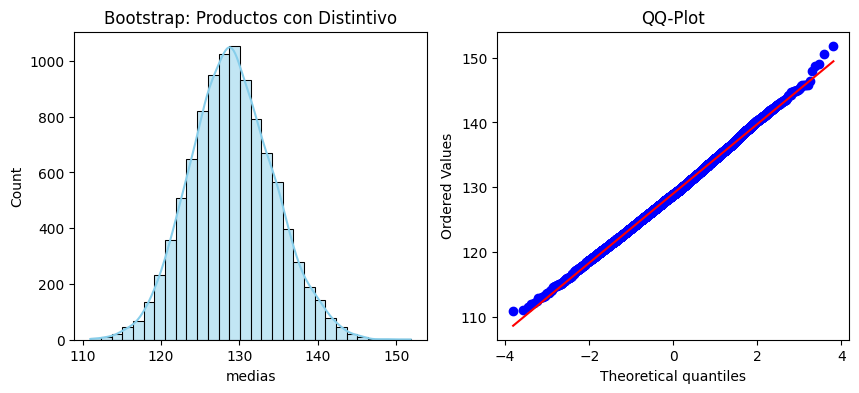

d:\Documentos\diego\Master\Amazon-Smart-Pricing\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.



Estadístico: 0.9989256872863815
p-valor: 3.5742123537611195e-06
Los datos NO siguen una distribución normal.


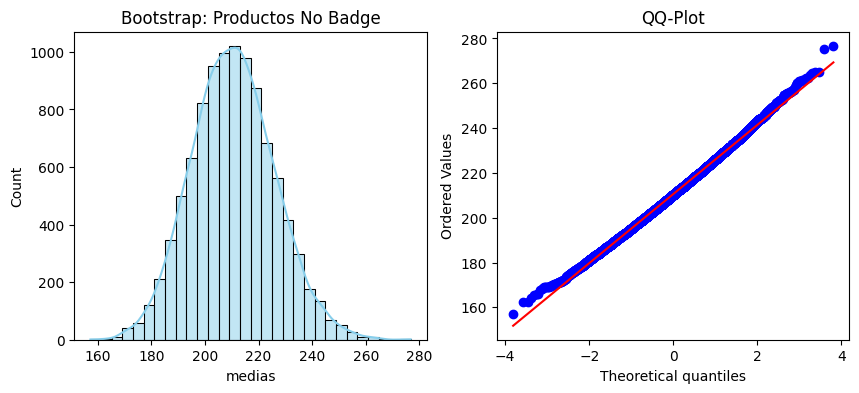

Estadístico: 0.9983694357358246
p-valor: 1.0340092150665866e-08
Los datos NO siguen una distribución normal.


d:\Documentos\diego\Master\Amazon-Smart-Pricing\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.



In [62]:
badge_exito = ["Amazon's", "Save 17%", "Best Seller"]

grupo_exito = df_audio[df_audio['is_best_seller'].isin(badge_exito)]['original_price'].dropna()
grupo_no_badge = df_audio[df_audio['is_best_seller'] == "No Badge"]['original_price'].dropna()

df_boot_exito = boot(grupo_exito)
df_boot_no_badge = boot(grupo_no_badge)

paint(df_boot_exito, "Productos con Distintivo")
test_normalidad(stats.shapiro, df_boot_exito["medias"])

paint(df_boot_no_badge, "Productos No Badge")
test_normalidad(stats.shapiro, df_boot_no_badge["medias"])

Estudiamos ahora la diferencias de sus varianzas con el test de Levene, sin asumir normalidad

In [ ]:
stat_lev, p_lev = stats.levene(grupo_exito, grupo_no_badge)
print(f"\n--- TEST DE LEVENE (Varianzas) ---\nP-valor: {p_lev}")


--- TEST DE LEVENE (Varianzas) ---
P-valor: 4.282801067408118e-06


Al ser mucho menor que 0.05, rechazamos que las varianzas sean iguales

In [ ]:
grupo_exito.std(), grupo_no_badge.std()

(93.77742757127568, 269.72242899087524)

Gracias a esto podemos observar que los productos que consiguen etiquetas de Amazon son, de media, casi 3 veces más baratos que los que no tienen etiqueta

Como las varianzas son distintas (visto en Levene) y los datos no son normales, utilizaremos el test de Mann-Whitney U para confirmar que esa diferencia de precio no es casualidad.

H0: No hay diferencia significativa en el precio entre los productos con etiqueta de éxito y los que no la tienen.

H1: Los productos con etiqueta de éxito tienen precios significativamente más bajos

C:\Users\diego\AppData\Local\Temp\ipykernel_16128\1889153998.py:3: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



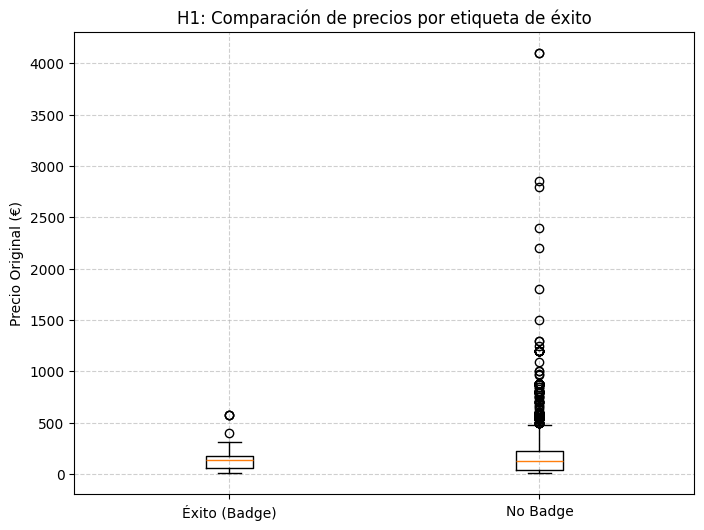

Estadístico U: 228363.50
Valor p: 0.08679084

RESULTADO: No se puede rechazar H0.
No se detecta una diferencia de precio significativa entre grupos.


In [63]:
# Gráfico de cajas
plt.figure(figsize=(8,6))
plt.boxplot([grupo_exito, grupo_no_badge], labels=["Éxito (Badge)", "No Badge"])
plt.title("H1: Comparación de precios por etiqueta de éxito")
plt.ylabel("Precio Original (€)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 3. Prueba de Mann-Whitney U para la Hipótesis
stat, p = mannwhitneyu(grupo_exito, grupo_no_badge, alternative='two-sided')

print(f"Estadístico U: {stat:.2f}")
print(f"Valor p: {p:.8f}") 

if p < 0.05:
    print("\nRESULTADO: Rechazamos H0.")
    print("Hay una diferencia significativa en los precios de los productos.")
    print("Los productos con etiqueta de éxito tienen precios significativamente más bajos.")
else:
    print("\nRESULTADO: No se puede rechazar H0.")
    print("No se detecta una diferencia de precio significativa entre grupos.")

Esto significa que no existe evidencia estadística suficiente para afirmar que Amazon premia exclusivamente a los productos más baratos con etiquetas de éxito en la categoría de Audio. La diferencia observada en las medias probablemente se deba a la presencia de outliers extremos (productos profesionales de muy alto coste) en el grupo "No Badge",. Por lo tanto podemos observar que el precio no es el factor único ni determinante para obtener un distintivo de éxito.

## 2. ¿ Existe una diferencia significativa entre las ventas de los productos patrocinados y los que no?

In [64]:
df_audio[df_audio.is_sponsored == 'Sponsored'].purchased_last_month.mean(), df_audio[df_audio.is_sponsored == 'Organic'].purchased_last_month.mean()

(552.3809523809524, 282.6842837273992)

Parece que se han vendido el doble de productos patrocinados.

Comprobamos la normalidad de la variable "bought_in_last_month".

100%|██████████| 10000/10000 [00:01<00:00, 7338.81it/s]


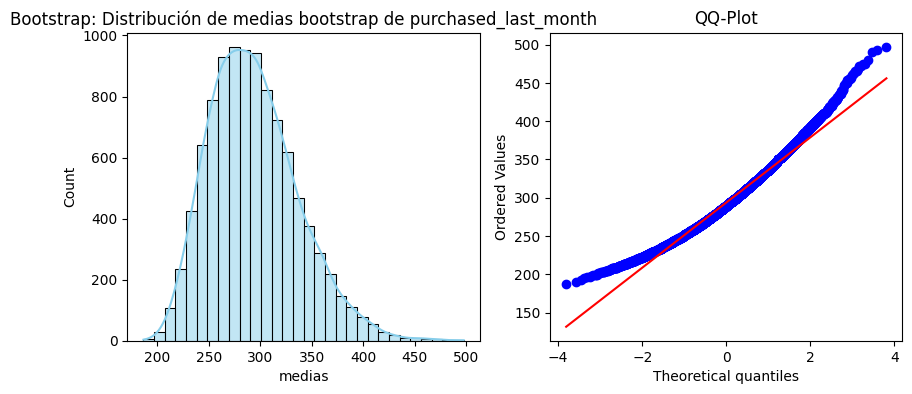

In [65]:
data = df_audio['purchased_last_month'].dropna()

df_boot = boot(data)

paint(df_boot, "Distribución de medias bootstrap de purchased_last_month")

In [66]:
test_normalidad(stats.shapiro,df_boot["medias"])


Estadístico: 0.9786787463936105
p-valor: 4.321175425484978e-36
Los datos NO siguen una distribución normal.


d:\Documentos\diego\Master\Amazon-Smart-Pricing\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.



In [67]:
test_normalidad(stats.normaltest,df_boot["medias"])

Estadístico: 573.8227319433108
p-valor: 2.488725302275389e-125
Los datos NO siguen una distribución normal.


Estudiamos ahora la diferencias de sus varianzas con el test de Levene, sin asumir normalidad

In [68]:
grupo1 = df_audio[df_audio.is_sponsored == 'Sponsored'].purchased_last_month.dropna()
grupo2 = df_audio[df_audio.is_sponsored == 'Organic'].purchased_last_month.dropna()

# Verificamos si las varianzas son realmente diferentes con la prueba de Levene
stat, p_var = stats.levene(grupo1, grupo2)
print(f"Prueba de Levene (varianza): p-value = {p_var:.8f}. Estadístico: {stat:.4f}")

Prueba de Levene (varianza): p-value = 0.00002756. Estadístico: 17.6339


Al ser mucho menor que 0.05, rechazamos que las varianzas sean iguales

Aplicamos entonces el test de Welch, usado como la prueba de t-Student para variables de varianza desigual.

In [69]:
# Aplicamos la prueba de Welch (t-test con varianzas desiguales)
t_stat, p_value = stats.ttest_ind(grupo1, grupo2, equal_var=False)

print(f"\nPrueba de Welch:")
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

# Interpretación del resultado
alpha = 0.05
if p_value < alpha:
    print("Las medias son significativamente diferentes.")
else:
    print("No hay evidencia suficiente para afirmar que las medias son diferentes.")


Prueba de Welch:
Estadístico t: 2.1745
Valor p: 0.0315
Las medias son significativamente diferentes.


Una vez realizadas las pruebas necesarias, puedo afirmar que la diferencia de las ventas entre productos Patrocinados y Orgánicos es estadísticamente significativa

# CORRELACIONES

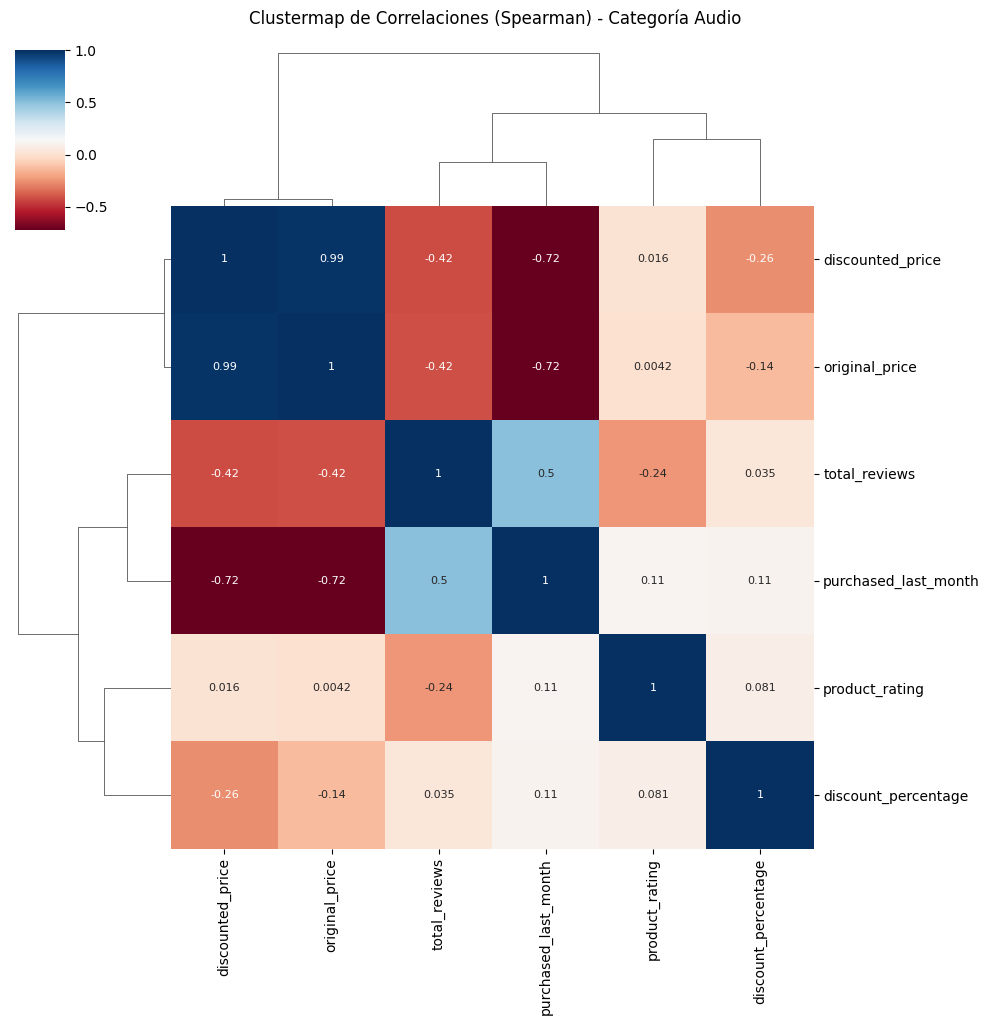

In [71]:
# Generamos el Clustermap utilizando la correlación de Spearman
g = sns.clustermap(df_audio[['product_rating', 'total_reviews', 'purchased_last_month', 'discounted_price', 'original_price', 'discount_percentage']].corr(method='spearman'),
                   method = 'complete',
                   cmap   = 'RdBu',
                   annot  = True,
                   annot_kws = {'size': 8},
                   figsize = (10, 10))

# Ajustamos el título para que quede bien posicionado
g.fig.suptitle('Clustermap de Correlaciones (Spearman) - Categoría Audio', y=1.02)
plt.show()

En el sector del Audio de Amazon, los datos son muy "traicioneros". Tenemos cables de 5 € conviviendo con camaras de 4.000 €, y productos con 10 reseñas junto a otros con 160.000. Si usáramos la correlación normal (Pearson), esos productos carísimos o súper populares estirarían tanto la escala que romperían el análisis. Spearman soluciona esto fijándose en el orden (ranking) y no en el valor exacto, lo que lo hace mucho más robusto frente a esos valores atípicos (outliers).

*1. Las Correlaciones más Fuertes:*

**Precio Original vs. Precio Descontado:** Esta es la más obvia. Si el precio base sube, el rebajado también suele hacerlo. En el clustermap, estas dos variables forman un "clúster" o grupo muy apretado porque se mueven casi al unísono.

**Total de Reseñas vs. Ventas Mensuales:** Suele ser la segunda más fuerte. En Audio, nadie se la juega con un equipo que no tenga opiniones. Cuantas más reseñas tiene un producto (prueba social), más confianza genera y más vende.

*2. Las Correlaciones más Débiles o Inexistentes:*

**Rating vs. Precio:** Esta es la gran sorpresa del Audio. Muchas veces la correlación es casi cero. ¿Por qué? Porque un adaptador de 8 € puede tener 5 estrellas por funcionar bien, mientras que unos cascos de 500 € pueden tener un 4.2 porque el comprador experto es mucho más exigente. El precio no garantiza una mejor nota.

**Descuento (%) vs. Rating:** El hecho de que un producto tenga un 40% de descuento no hace que a la gente le guste más. La satisfacción (rating) depende de la calidad del sonido, no de lo barata que fuera la oferta.

*3. Conclusión:* 

El mercado de Audio en Amazon se mueve por confianza (reviews) y no tanto por "calidad técnica pagada" (precio vs rating). Los grupos que forma el clustermap confirman que una estrategia de éxito debe centrarse en acumular opiniones más que en simplemente subir el precio esperando que el cliente perciba más valor.